### SIGMOID is just an replacement of np.sign here. So, it is just an error function giving {1, 0}.
Sum of losses from every point will make the cost function. We choose a method for this as CROSS-ENTROPY LOSS.

Let H(x) be thetaX+theta0 be on x-axis, and sigmoid(H(x)) be on y-axis. So, for x-values >0, y-values be greater than 0.5. While for x-values <0, y-values will be <0.5

sigmoid(H(x)) close to 1 means it is correctly classified ==> Theta*X+theta0 > 0. sigmoid(H(x)) close to 0 means it is incorrectly classified ==> Theta*X+theta0 < 0. sigmoid(H(x)) close to 0.5 ==> inconclusive classification.
For correctly classified +ve label data, P(X)=sigmoid(H(X))->1.
For correctly classified -ve label data, P(X)=(1 - sigmoid(H(X))) ->1. {As sigmoid for correctly classified -ve label data X will be 0. So, to fit in principle of correct classification => +1 probability, we did}

Total probability of each points gets correctly classified P(all_X) = P(x1) * p(x2) * ... * P(xN).

We need this to be maximised. But loss needs to be minimized. So, we'll take negative of (LOG OF THIS)

This is called cross-entropy loss. AKA, negative loss likelihood. AKA, negative log likelihood.

Since y (the labels are just 0 and 1). Therefore, above will be represented as L = -MEAN[y(i) * log(sigmoid(H(X)))  +  (1-y(i)) * log(1-sigmoid(H(X)))]; where H(X)=theta*X+theta0

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Define the data points
x = np.array([1, 2, -1, -2])    # Feature values
y = np.array([1, 1, 0, 0])      # Corresponding labels (1 for positive class, 0 for negative class)

In [3]:
# Sigmoid Function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [ ]:
# Cross entropy loss function:
def cross_entropy_loss(x, y, theta, theta0):
    z = theta * x + theta0
    predictions = sigmoid(z)
    # preds = np.clip(preds, eps, 1 - eps)   # avoid log(0)
    # Calculate cross-entropy loss
    loss = -np.mean(y * np.log(predictions + 1e-15) + (1 - y) * np.log(1 - predictions + 1e-15))
    return loss

In [10]:
# Values of theta and theta0 to use
theta_values = [1, -1, 2, -2]   # Corresponding theta values
theta0_values = [0, 1, -1, 2]   # Corresponding theta0 values

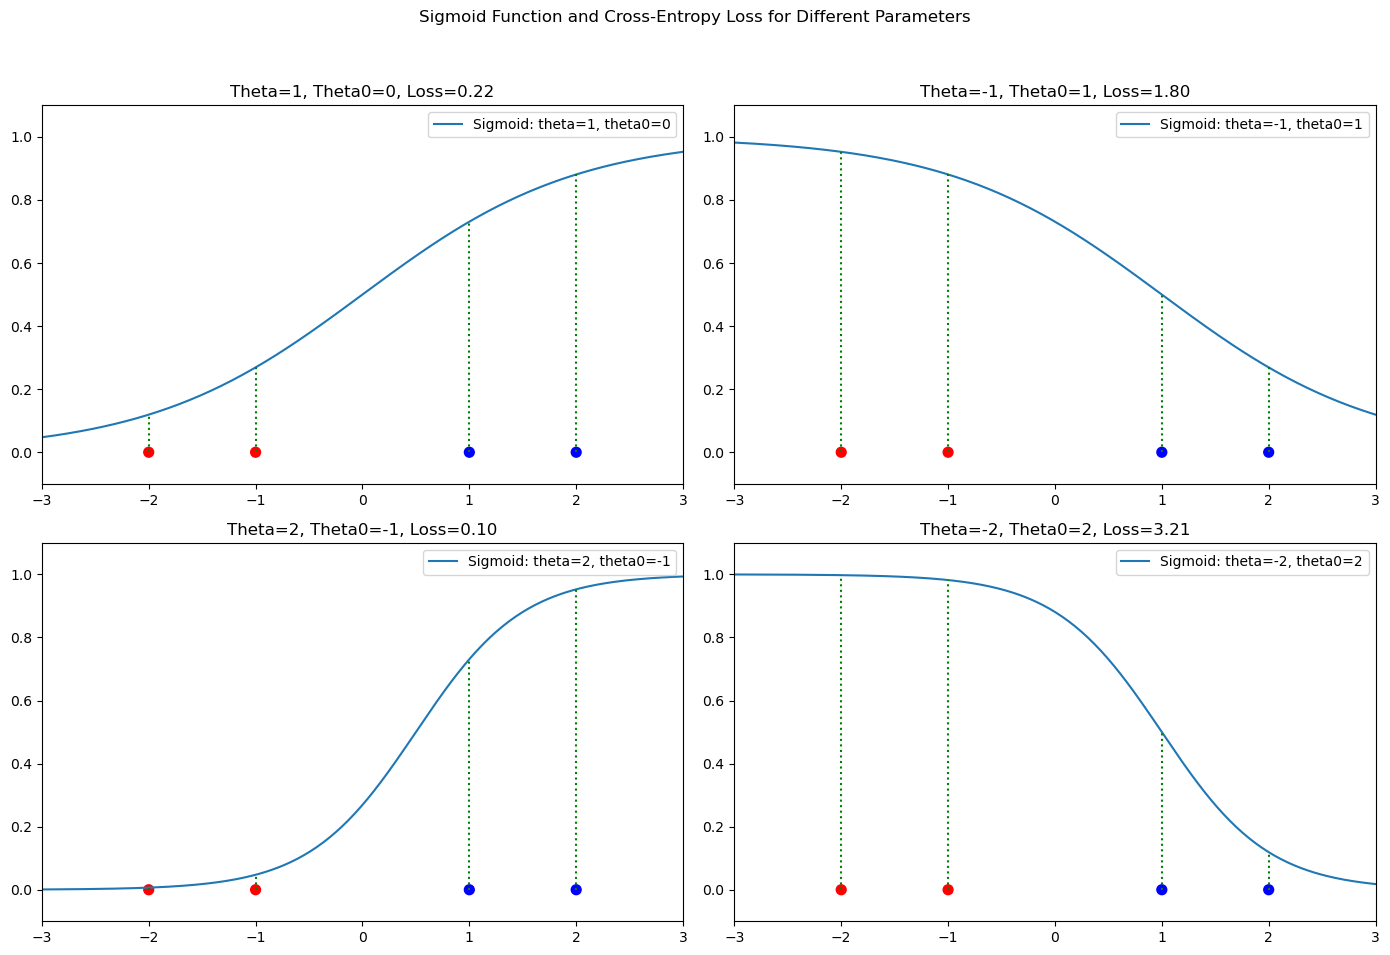

In [12]:
# Plot setup
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Sigmoid Function and Cross-Entropy Loss for Different Parameters')

for ax, theta, theta0 in zip(axes.flatten(), theta_values, theta0_values):
    # Generate a range of x values for plotting the sigmoid
    x_range = np.linspace(-3, 3, 300)
    z = theta * x_range + theta0
    p = sigmoid(z)
    
    # Plot the sigmoid curve
    ax.plot(x_range, p, label=f'Sigmoid: theta={theta}, theta0={theta0}')
    
    # Highlight data points on x-axis
    ax.scatter(x, np.zeros_like(x), c=['blue' if label == 1 else 'red' for label in y], s=50)
    ax.vlines(x, 0, sigmoid(theta * x + theta0), color='green', linestyle='dotted')
    
    # Calculate and display the loss
    loss = cross_entropy_loss(x, y, theta, theta0)
    ax.title.set_text(f"Theta={theta}, Theta0={theta0}, Loss={loss:.2f}")
    
    ax.set_xlim([-3, 3])
    ax.set_ylim([-0.1, 1.1])
    ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])